# Example-16: Virtual matrix

In [1]:
# Import

import numpy
import pandas
import torch

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [3]:
# In this example transport matrices are computed between locations from TbT signals

# Transport matrix i -> j can be written as M(i -> j) = N(j) R(i -> j) N(i)^-1
# Normalization matrices and phase advances can be computed from TbT data at monitor locations
# At virtual locations no TbT data is avaliable. but virtual normalization matrices and phase advances can be computed
# If the model is close to real lattice, virtual parameters are close to the real ones
# See Virtual twiss example and Momenta estimation & virtual trajectories for details
# Here virtual phases and twiss are computed from virtual signals

# Another option is to partially use model transport (twiss.matrix_virtual)

In [4]:
# Set model 

model = Model(path='../config.yaml', dtype=dtype, device=device)

# Set monitor and virtual location names (excluding 'HEAD' and 'TAIL' locations)

monitor = model.name[1:-1:2]
virtual = model.name[2:-1:2]

# Modify model dictionary

for location in monitor: model.dict[location]['TYPE'] = model._monitor ; model.dict[location]['FLAG'] = 1
for location in virtual: model.dict[location]['TYPE'] = model._virtual ; model.dict[location]['FLAG'] = 0

# Set modified model

model = Model(path=model.dict, dtype=dtype, device=device)

# Set errors

model.make_error(0.5E-3, 0.5E-3, length=0.001)

# Set transport

model.make_transport(error=True, exact=False)

# Compute twiss

model.make_twiss()
print(model.is_stable)

# Set fractional tunes

NUX, NUY = model.out_tune_fractional

# Set free normalization matrix elements

N11 = model.out_normal[:, 0, 0]
N33 = model.out_normal[:, 2, 2]
N21 = model.out_normal[:, 1, 0]
N43 = model.out_normal[:, 3, 2]
N13 = model.out_normal[:, 0, 2]
N31 = model.out_normal[:, 2, 0]
N14 = model.out_normal[:, 0, 3]
N41 = model.out_normal[:, 3, 0]

# Set CS twiss

AX, BX, AY, BY = model.out_cs.T


# Set accumulated phase advance

MUX, MUY = model.out_advance.roll(1, 0).cumsum(0).T

True


torch.Size([59, 4096, 4])

4.213455744e-07, 6.455278193e-19
1.832239409e-07, 1.543465499e-20



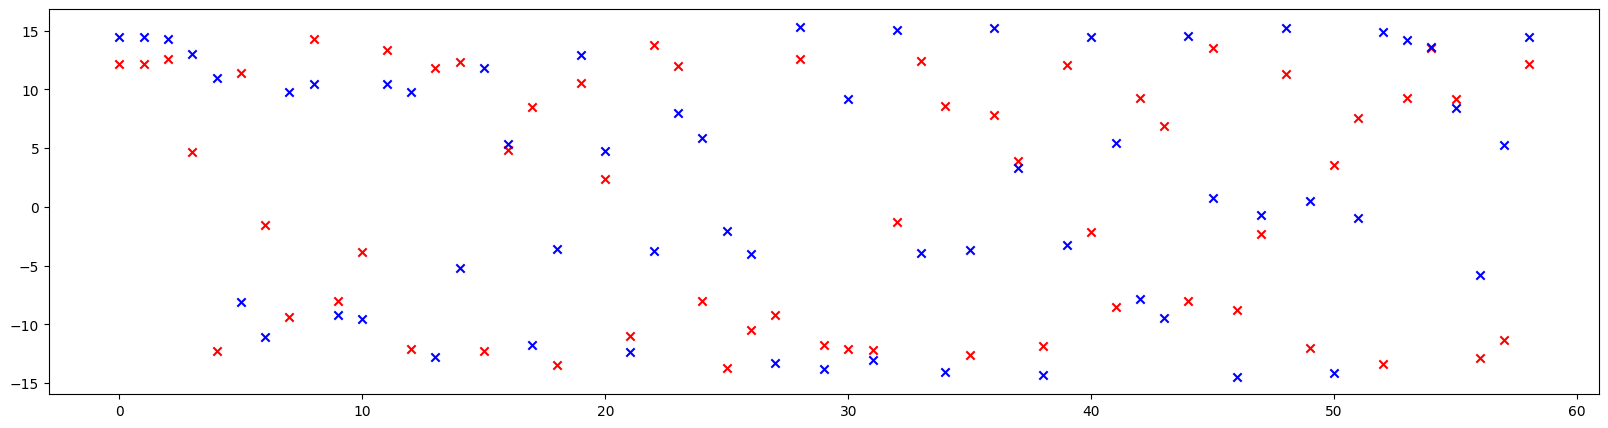

In [5]:
# Generate test trajectories

# Set initial condition

initial = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**12

# Generate trajectories

trajectory =  model.make_trajectory(initial, length, error=True, transport=True)
print(trajectory.shape)
print()

# Set x & y coordinates at each monitor location

x = trajectory[model.monitor_index, ..., 0]
y = trajectory[model.monitor_index, ..., 2]

# Compute reference invariant values using selected trajectory

# Set trajectory index

index = 0

# Compute invariants

from harmonica.parameterization import invariant
action_x, action_y = invariant(model.out_normal[index], trajectory[index])

print(f'{action_x.mean().item():>12.9e}, {action_x.std().item():>12.9e}')
print(f'{action_y.mean().item():>12.9e}, {action_y.std().item():>12.9e}')
print()

action_x = action_x.mean()
action_y = action_y.mean()

# Compare model and real beta function values

from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

plt.figure(figsize=(20, 5))
plt.scatter(range(model.size), 100*(BX - model.bx)/model.bx, color='red', marker='x')
plt.scatter(range(model.size), 100*(BY - model.by)/model.by, color='blue', marker='x')
plt.show()

NUX= 0.545100606
nux= 0.545100606, sigma_nux=3.35925903e-16, error_nux=1.11022302e-16

NUY= 0.573070567
nuy= 0.573070567, sigma_nuy=6.87331051e-16, error_nuy=1.11022302e-15



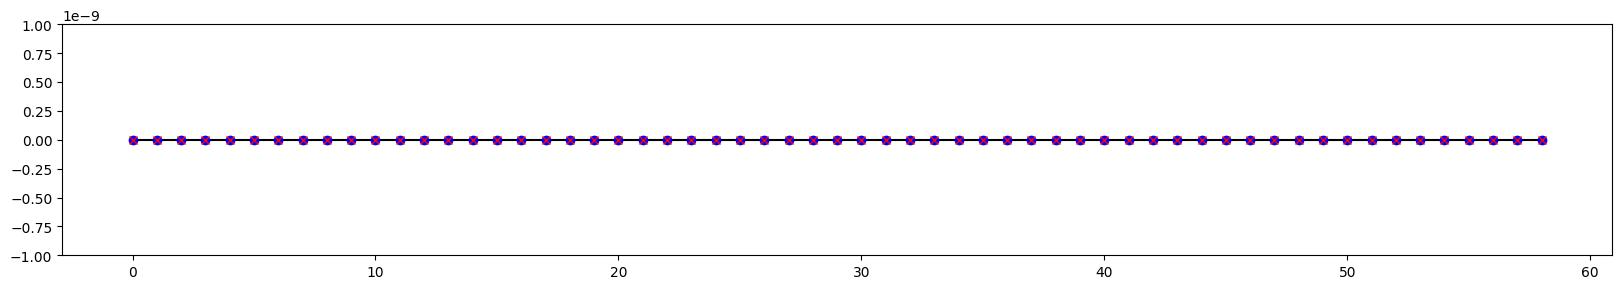

In [6]:
# Compute reference parameters from clean data at all locations

# Set window

win = Window.from_cosine(length, 2.0, dtype=dtype, device=device)

# Estimate frequency, amplitude and phase for x plane

tbt = Data.from_data(win, trajectory[..., 0])

f = Frequency(tbt)
tbt.window_remove_mean()
tbt.window_apply()
f('parabola')
tbt.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUX={NUX.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(NUX - nux).item():12.9}')
print()

d = Decomposition(tbt)
ax_ref, sigma_ax, *_ = d.harmonic_amplitude(nux, length=2048, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=512, step=16, method='none')
fx_ref, sigma_fx, *_ = d.harmonic_phase(nux, length=2048, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=512, step=16, method='none')

# Estimate frequency, amplitude and phase for y plane

tbt = Data.from_data(win, trajectory[..., 2])

f = Frequency(tbt)
tbt.window_remove_mean()
tbt.window_apply()
f('parabola')
tbt.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUY={NUY.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(NUY - nuy).item():12.9}')
print()

d = Decomposition(tbt)
ay_ref, sigma_ay, *_ = d.harmonic_amplitude(nuy, length=2048, order=2.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=512, step=16, method='none')
fy_ref, sigma_fy, *_ = d.harmonic_phase(nuy, length=2048, order=2.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=512, step=16, method='none')

# Phase advance between locations

plt.figure(figsize=(20, 3))

ADVANCE, _ = Decomposition.phase_adjacent(NUX, MUX)
advance, _ = Decomposition.phase_adjacent(nux, fx_ref)

plt.errorbar(range(model.size), mod(ADVANCE - advance, 2.0*numpy.pi, -numpy.pi).cpu().numpy(), fmt=' ', marker='o', color='blue')

ADVANCE, _ = Decomposition.phase_adjacent(NUY, MUY)
advance, _ = Decomposition.phase_adjacent(nuy, fy_ref)

plt.errorbar(range(model.size), mod(ADVANCE - advance, 2.0*numpy.pi, -numpy.pi).cpu().numpy(), fmt=' ', marker='x', color='red')

plt.ylim(-1.0E-9, +1.0E-9)
plt.hlines(0, 0, model.size - 1, colors='black')

plt.show()

In [7]:
# Generate TbT data with noise

# Set noise values for each monitor location 

noise_x = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
noise_y = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

# Set length

length = 2**10

# Set window

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

# Set TbT & add noise

X = Data.from_data(win, x[:, :length])
X.add_noise(noise_x)
X.data.copy_(X.work)
X.reset()
print(X)

Y = Data.from_data(win, y[:, :length])
Y.add_noise(noise_y)
Y.data.copy_(Y.work)
Y.reset()
print(Y)

Data(29, Window(1024, 'cosine_window', 1.0))
Data(29, Window(1024, 'cosine_window', 1.0))


In [8]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUX={NUX.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(NUX - nux).item():12.9}')
print()

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, clean=True, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=256, order=0.5, clean=True, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

print((ax - ax_ref[model.monitor_index]).abs().sum().item())
print((fx - fx_ref[model.monitor_index]).abs().sum().item())

NUX= 0.545100606
nux= 0.545100611, sigma_nux=1.35197462e-07, error_nux=4.33463199e-09

1.1174700096850364e-05
0.005039708943179372


In [9]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUY={NUY.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(NUY - nuy).item():12.9}')
print()

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, clean=True, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=256, order=0.5, clean=True, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

print((ay - ay_ref[model.monitor_index]).abs().sum().item())
print((fy - fy_ref[model.monitor_index]).abs().sum().item())

NUY= 0.573070567
nuy= 0.573070578, sigma_nuy=1.20686144e-07, error_nuy=1.08192344e-08

1.0739927736887808e-05
0.0040683611754524646


In [10]:
# Set table

table = Table(
    model.monitor_name,
    nux, nuy, ax, ay, fx, fy,
    sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy,
    x=X.data,
    y=Y.data,
    accumulate=True,
    dtype=dtype, device=device)

# Compare phase advance between adjacent monitor locations

mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(NUX, mux)
muy, _ = Decomposition.phase_adjacent(NUY, muy)

print((mux - table.phase_x).abs().sum().item())
print((muy - table.phase_y).abs().sum().item())
print()

0.0074990992084618124
0.006180154760481338



In [11]:
# Set twiss

twiss = Twiss(model, table)

In [12]:
# Generate virtual signals

# Note, limit selection can be motivated by how accurate is the model
# Minimal value is one and it should be used if model if off
# Larger values can improve accuracy if model is more accurate

start = 1
count = length - 1 - start
limit = 1

VQX = torch.zeros((model.virtual_count, length), dtype=dtype, device=device)
VPX = torch.zeros((model.virtual_count, length), dtype=dtype, device=device)
VQY = torch.zeros((model.virtual_count, length), dtype=dtype, device=device)
VPY = torch.zeros((model.virtual_count, length), dtype=dtype, device=device)

for index, location in enumerate(model.virtual_index):
    
    qx, px, qy, py = twiss.get_momenta_lstsq(start, count, location, limit, model.matrix, phony=True, forward=True, inverse=True)
    
    VQX[index, :count] = qx
    VPX[index, :count] = px
    
    VQY[index, :count] = qy
    VPY[index, :count] = py

In [13]:
# Set TbT

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

X = Data.from_data(win, VQX)
Y = Data.from_data(win, VQY)

print(X)
print(Y)

Data(30, Window(1024, 'cosine_window', 1.0))
Data(30, Window(1024, 'cosine_window', 1.0))


In [14]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUX={NUX.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(NUX - nux).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, clean=True, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=256, order=0.5, clean=True, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

# Shift phase

fx = mod(fx - 2.0*numpy.pi*start*nux, 2.0*numpy.pi, -numpy.pi)

NUX= 0.545100606
nux= 0.545100595, sigma_nux=1.6238674e-07, error_nux=1.11079418e-08


In [15]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'NUY={NUY.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(NUY - nuy).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, clean=True, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=256, order=0.5, clean=True, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

# Shift phase

fy = mod(fy - 2.0*numpy.pi*start*nuy, 2.0*numpy.pi, -numpy.pi)

NUY= 0.573070567
nuy= 0.573070645, sigma_nuy=3.32463479e-07, error_nuy=7.78231215e-08


In [16]:
# Set virtual phases

twiss.fx[model.virtual_index] = fx
twiss.fy[model.virtual_index] = fy

twiss.sigma_fx[model.virtual_index] = sigma_fx
twiss.sigma_fy[model.virtual_index] = sigma_fy

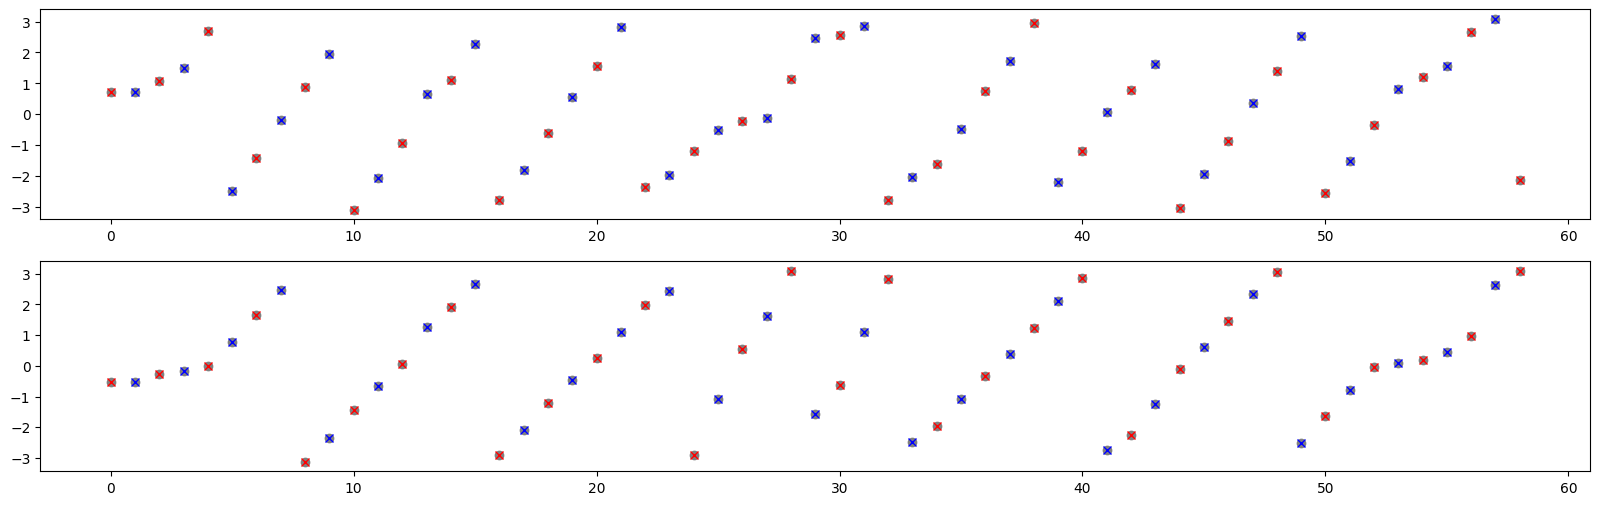

In [17]:
# Compare phases

plt.figure(figsize=(20, 2*3))

ax1 = plt.subplot(211)
ax1.scatter(range(model.size), fx_ref.cpu().numpy(), marker='o', color='gray')
ax1.errorbar(model.monitor_index, mod(twiss.fx[model.monitor_index], 2.0*numpy.pi, -numpy.pi).cpu().numpy(), yerr=twiss.sigma_fx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax1.errorbar(model.virtual_index, mod(twiss.fx[model.virtual_index], 2.0*numpy.pi, -numpy.pi).cpu().numpy(), yerr=twiss.sigma_fx[model.virtual_index].cpu().numpy(), fmt=' ', marker='x', color='red')

ax2 = plt.subplot(212)
ax2.scatter(range(model.size), fy_ref.cpu().numpy(), marker='o', color='gray')
ax2.errorbar(model.monitor_index, mod(twiss.fy[model.monitor_index], 2.0*numpy.pi, -numpy.pi).cpu().numpy(), yerr=twiss.sigma_fy[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax2.errorbar(model.virtual_index, mod(twiss.fy[model.virtual_index], 2.0*numpy.pi, -numpy.pi).cpu().numpy(), yerr=twiss.sigma_fy[model.virtual_index].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

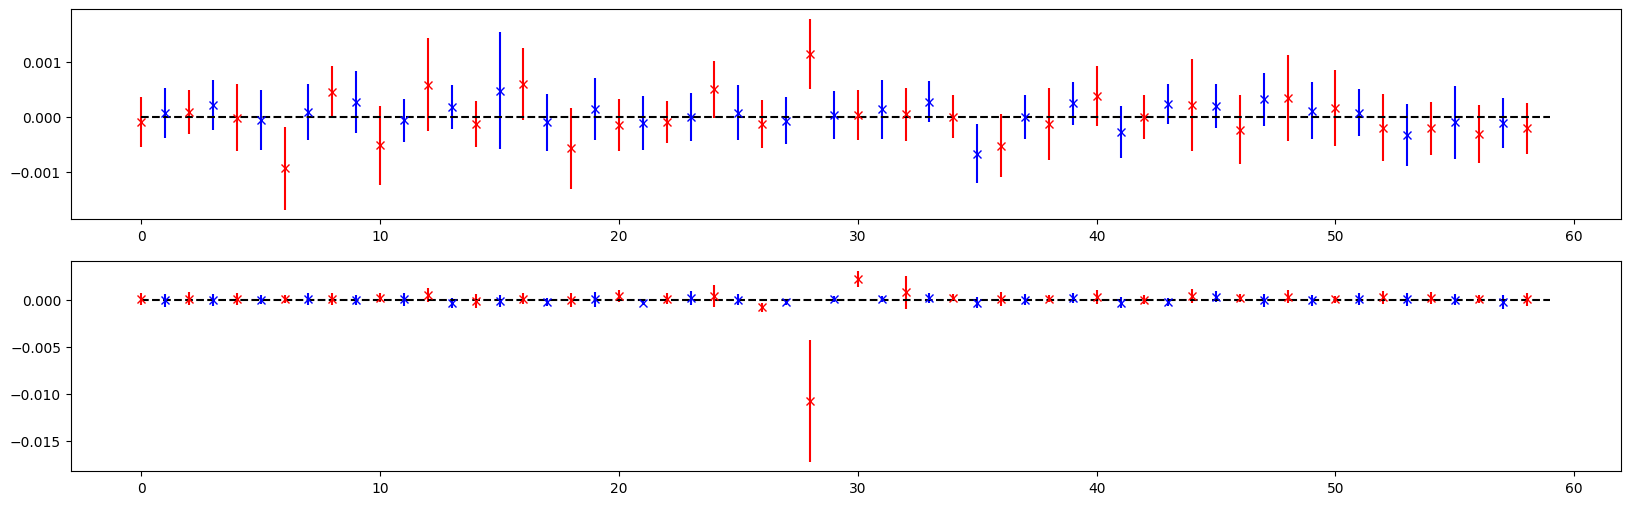

In [18]:
# Compare phases

plt.figure(figsize=(20, 2*3))

ax1 = plt.subplot(211)
ax1.errorbar(model.monitor_index, (fx_ref[model.monitor_index] - mod(twiss.fx[model.monitor_index], 2.0*numpy.pi, -numpy.pi)).cpu().numpy(), yerr=twiss.sigma_fx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax1.errorbar(model.virtual_index, (fx_ref[model.virtual_index] - mod(twiss.fx[model.virtual_index], 2.0*numpy.pi, -numpy.pi)).cpu().numpy(), yerr=twiss.sigma_fx[model.virtual_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax1.hlines(0, 0, model.size, linestyles='dashed', color='black')

ax2 = plt.subplot(212)
ax2.errorbar(model.monitor_index, (fy_ref[model.monitor_index] - mod(twiss.fy[model.monitor_index], 2.0*numpy.pi, -numpy.pi)).cpu().numpy(), yerr=twiss.sigma_fy[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax2.errorbar(model.virtual_index, (fy_ref[model.virtual_index] - mod(twiss.fy[model.virtual_index], 2.0*numpy.pi, -numpy.pi)).cpu().numpy(), yerr=twiss.sigma_fy[model.virtual_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax2.hlines(0, 0, model.size, linestyles='dashed', color='black')

plt.show()

In [19]:
%%time

# Estimate twiss

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1,
                                 256,
                                 parametric_normal,
                                 model.matrix,
                                 twiss=None,
                                 method='lstsq',
                                 limit=2,
                                 product=True,
                                 jacobian=False,
                                 count=256,
                                 fraction=0.75,
                                 ix=None,
                                 iy=None,
                                 sigma=1.0E-3,
                                 n_jobs=12,
                                 verbose=False)
print(data.shape)

torch.Size([29, 2, 10, 256])
CPU times: user 26.2 s, sys: 1.06 s, total: 27.3 s
Wall time: 39.6 s


In [20]:
# Process fitted invariants

ix, iy = data[:, 0, 0], data[:, 0, 1]
sigma_ix, sigma_iy = data[:, 1, 0], data[:, 1, 1]
invariant = twiss.get_invariant(ix, iy, sigma_ix, sigma_iy)

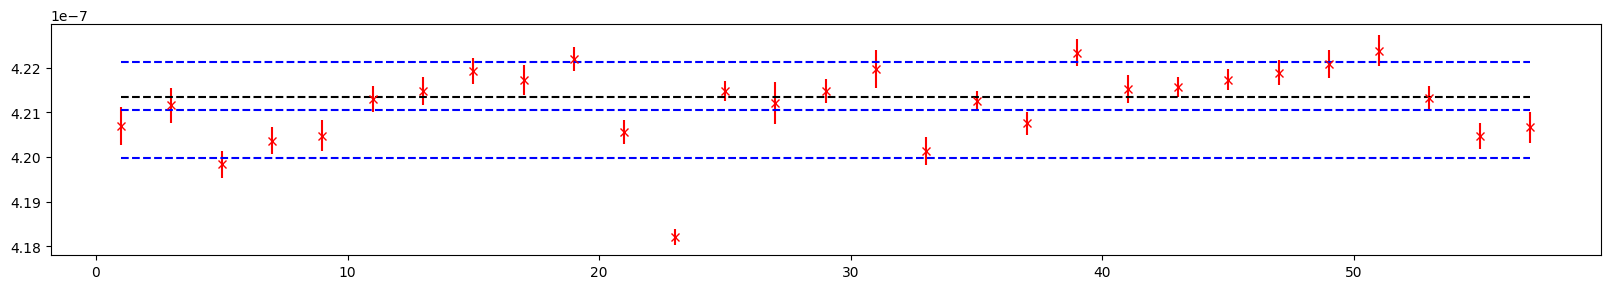

tensor(4.213455744355e-07, dtype=torch.float64)
tensor(4.210501033211e-07, dtype=torch.float64)
tensor(1.079285441417e-09, dtype=torch.float64)



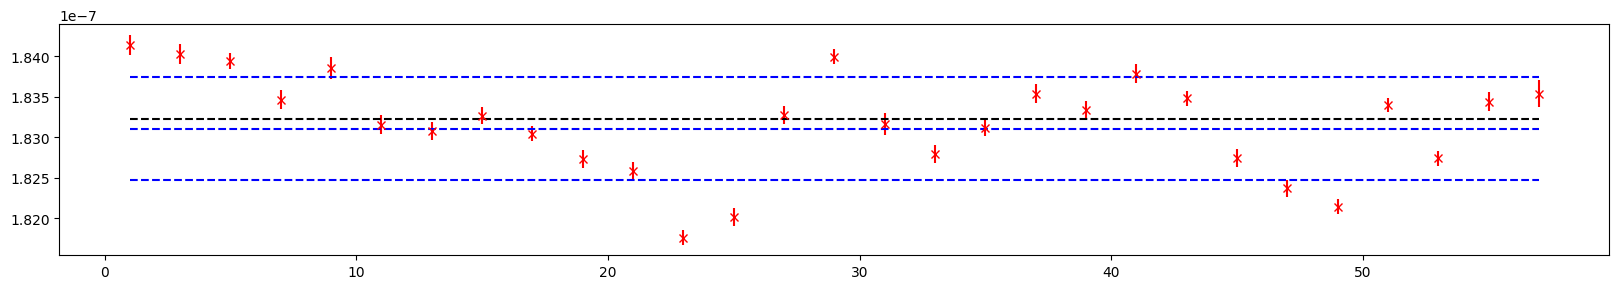

tensor(1.832239408856e-07, dtype=torch.float64)
tensor(1.831049412561e-07, dtype=torch.float64)
tensor(6.367222965921e-10, dtype=torch.float64)



In [21]:
# Plot invariants for each signal

plt.figure(figsize=(20, 3))
plt.errorbar(model.monitor_index, invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_x, min(model.monitor_index), max(model.monitor_index), linestyles='dashed', color='black')
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], min(model.monitor_index), max(model.monitor_index), linestyles='dashed', color='blue')
plt.show()

print(action_x)
print(invariant['ix_value'])
print(invariant['ix_error'])
print()

plt.figure(figsize=(20, 3))
plt.errorbar(model.monitor_index, invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_y, min(model.monitor_index), max(model.monitor_index), linestyles='dashed', color='black')
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], min(model.monitor_index), max(model.monitor_index), linestyles='dashed', color='blue')
plt.show()

print(action_y)
print(invariant['iy_value'])
print(invariant['iy_error'])
print()

In [22]:
# Process twiss

mask = invariant['ix_mask']*invariant['sx_mask']*invariant['iy_mask']*invariant['sy_mask']

value, error = data.permute(1, 2, 0, -1)

*_, value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41 = value
*_, error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41 = error

value_n11, error_n11 = twiss.process(value_n11, error_n11, mask=mask)
value_n33, error_n33 = twiss.process(value_n33, error_n33, mask=mask)
value_n21, error_n21 = twiss.process(value_n21, error_n21, mask=mask)
value_n43, error_n43 = twiss.process(value_n43, error_n43, mask=mask)
value_n13, error_n13 = twiss.process(value_n13, error_n13, mask=mask)
value_n31, error_n31 = twiss.process(value_n31, error_n31, mask=mask)
value_n14, error_n14 = twiss.process(value_n14, error_n14, mask=mask)
value_n41, error_n41 = twiss.process(value_n41, error_n41, mask=mask)

In [23]:
%%time

# Estimate twiss (virtual)

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1,
                                 256,
                                 parametric_normal,
                                 model.matrix,
                                 twiss=None,
                                 method='lstsq',
                                 limit=2,
                                 phony=True,
                                 product=True,
                                 jacobian=False,
                                 count=256,
                                 fraction=0.75,
                                 ix=invariant['ix_value'],
                                 iy=invariant['iy_value'],
                                 sigma=1.0E-3,
                                 n_jobs=12,
                                 verbose=False)
print(data.shape)
print(model.virtual_count)

torch.Size([30, 2, 8, 256])
30
CPU times: user 26.7 s, sys: 699 ms, total: 27.4 s
Wall time: 34.3 s


In [24]:
# Process twiss

value, error = data.permute(1, 2, 0, -1)

*_, value_v11, value_v33, value_v21, value_v43, value_v13, value_v31, value_v14, value_v41 = value
*_, error_v11, error_v33, error_v21, error_v43, error_v13, error_v31, error_v14, error_v41 = error

value_v11, error_v11 = twiss.process(value_v11, error_v11)
value_v33, error_v33 = twiss.process(value_v33, error_v33)
value_v21, error_v21 = twiss.process(value_v21, error_v21)
value_v43, error_v43 = twiss.process(value_v43, error_v43)
value_v13, error_v13 = twiss.process(value_v13, error_v13)
value_v31, error_v31 = twiss.process(value_v31, error_v31)
value_v14, error_v14 = twiss.process(value_v14, error_v14)
value_v41, error_v41 = twiss.process(value_v41, error_v41)

In [25]:
# Compute twiss at all locations from normalization

from harmonica.parameterization import parametric_normal
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_local, error_local in zip(value, error):
    table = value_local.reshape(-1, 1) + error_local.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax_m, value_bx_m, value_ay_m, value_by_m = cs_value.T
error_ax_m, error_bx_m, error_ay_m, error_by_m = cs_error.T

value = torch.stack([value_v11, value_v33, value_v21, value_v43, value_v13, value_v31, value_v14, value_v41]).T
error = torch.stack([error_v11, error_v33, error_v21, error_v43, error_v13, error_v31, error_v14, error_v41]).T

cs_value, cs_error = [], []

for value_local, error_local in zip(value, error):
    table = value_local.reshape(-1, 1) + error_local.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax_v, value_bx_v, value_ay_v, value_by_v = cs_value.T
error_ax_v, error_bx_v, error_ay_v, error_by_v = cs_error.T

In [26]:
# Set uncoupled

twiss.ax[model.monitor_index] = value_ax_m
twiss.bx[model.monitor_index] = value_bx_m
twiss.ay[model.monitor_index] = value_ay_m
twiss.by[model.monitor_index] = value_by_m

twiss.ax[model.virtual_index] = value_ax_v
twiss.bx[model.virtual_index] = value_bx_v
twiss.ay[model.virtual_index] = value_ay_v
twiss.by[model.virtual_index] = value_by_v

twiss.sigma_ax[model.monitor_index] = error_ax_m
twiss.sigma_bx[model.monitor_index] = error_bx_m
twiss.sigma_ay[model.monitor_index] = error_ay_m
twiss.sigma_by[model.monitor_index] = error_by_m

twiss.sigma_ax[model.virtual_index] = error_ax_v
twiss.sigma_bx[model.virtual_index] = error_bx_v
twiss.sigma_ay[model.virtual_index] = error_ay_v
twiss.sigma_by[model.virtual_index] = error_by_v

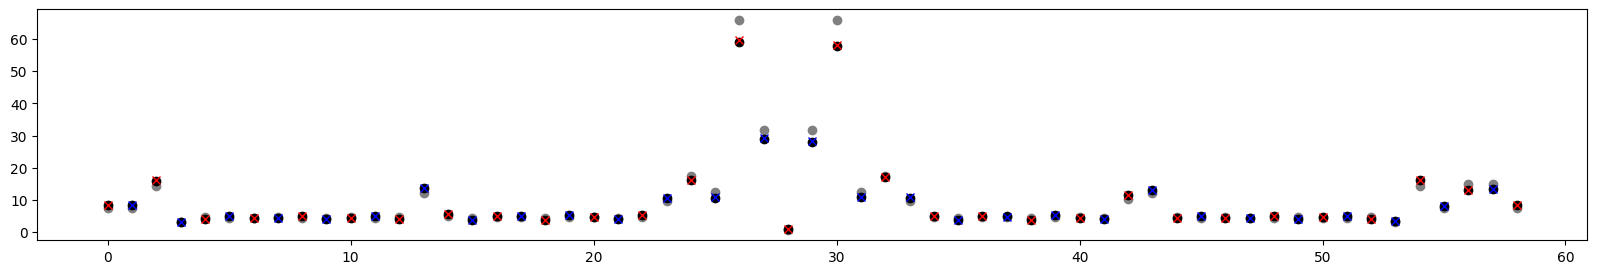

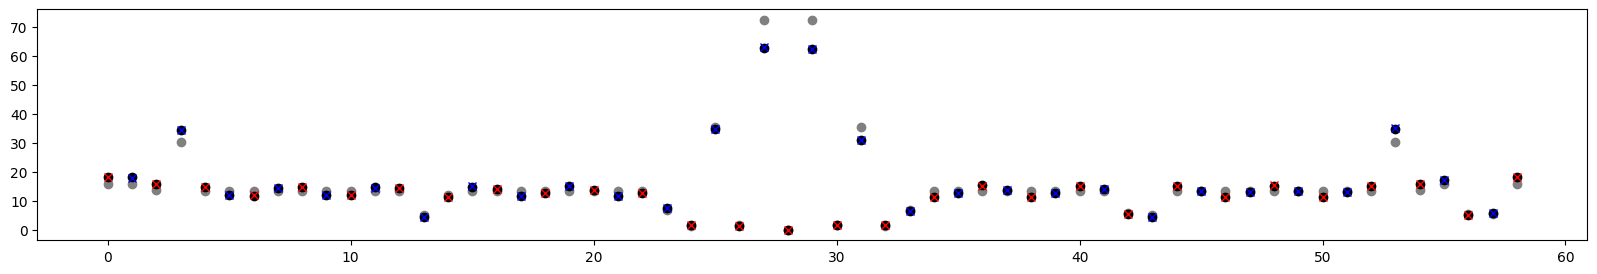

tensor(6.718818979800e-01, dtype=torch.float64)
tensor(9.903067352742e-01, dtype=torch.float64)

tensor(3.270261938259e-02, dtype=torch.float64)
tensor(3.257823856485e-01, dtype=torch.float64)



In [27]:
# Compare twiss

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.bx, color='gray', marker='o')
plt.scatter(range(model.size), BX, color='black', marker='o')
plt.errorbar(model.monitor_index, value_bx_m, yerr=error_bx_m, fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_bx_v, yerr=error_bx_v, fmt=' ', color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.by, color='gray', marker='o')
plt.scatter(range(model.size), BY, color='black', marker='o')
plt.errorbar(model.monitor_index, value_by_m, yerr=error_by_m, fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_by_v, yerr=error_by_v, fmt=' ', color='red', marker='x')
plt.show()

print((BX[model.monitor_index] - value_bx_m).sum().abs())
print((BX[model.virtual_index] - value_bx_v).sum().abs())
print()

print((BY[model.monitor_index] - value_by_m).sum().abs())
print((BY[model.virtual_index] - value_by_v).sum().abs())
print()

# gray  -- model values
# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

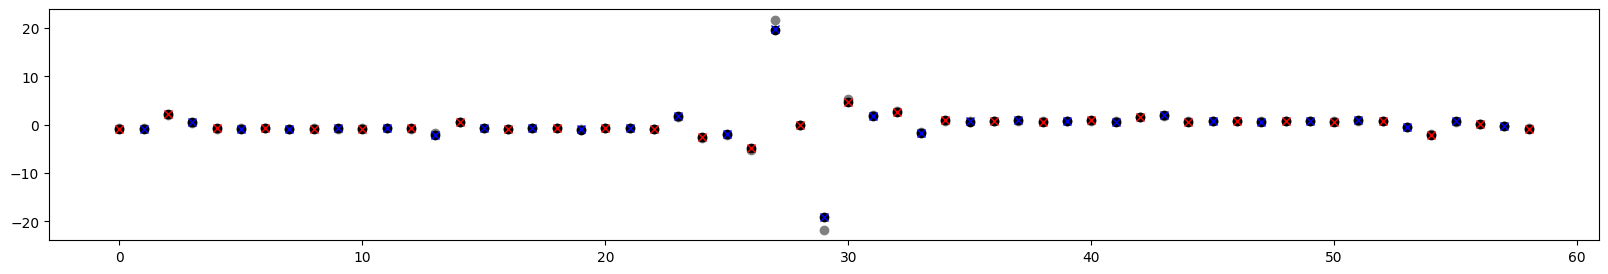

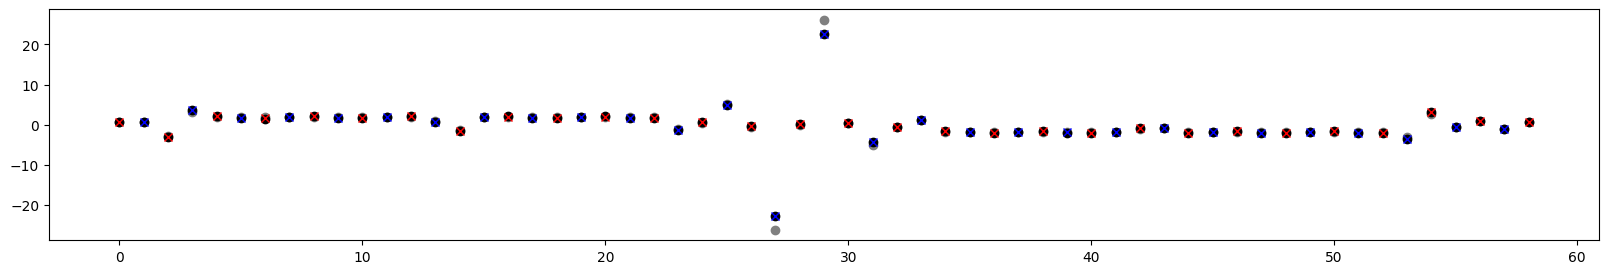

tensor(1.674168074547e-01, dtype=torch.float64)
tensor(2.703145488199e-02, dtype=torch.float64)

tensor(1.928303156503e-01, dtype=torch.float64)
tensor(2.501751410927e-02, dtype=torch.float64)



In [28]:
# Compare twiss

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.ax, color='gray', marker='o')
plt.scatter(range(model.size), AX, color='black', marker='o')
plt.errorbar(model.monitor_index, value_ax_m, yerr=error_ax_m, fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_ax_v, yerr=error_ax_v, fmt=' ', color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(model.size), model.ay, color='gray', marker='o')
plt.scatter(range(model.size), AY, color='black', marker='o')
plt.errorbar(model.monitor_index, value_ay_m, yerr=error_ay_m, fmt=' ', color='blue', marker='x')
plt.errorbar(model.virtual_index, value_ay_v, yerr=error_ay_v, fmt=' ', color='red', marker='x')
plt.show()

print((AX[model.monitor_index] - value_ax_m).sum().abs())
print((AX[model.virtual_index] - value_ax_v).sum().abs())
print()

print((AY[model.monitor_index] - value_ay_m).sum().abs())
print((AY[model.virtual_index] - value_ay_v).sum().abs())
print()

# gray  -- model values
# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

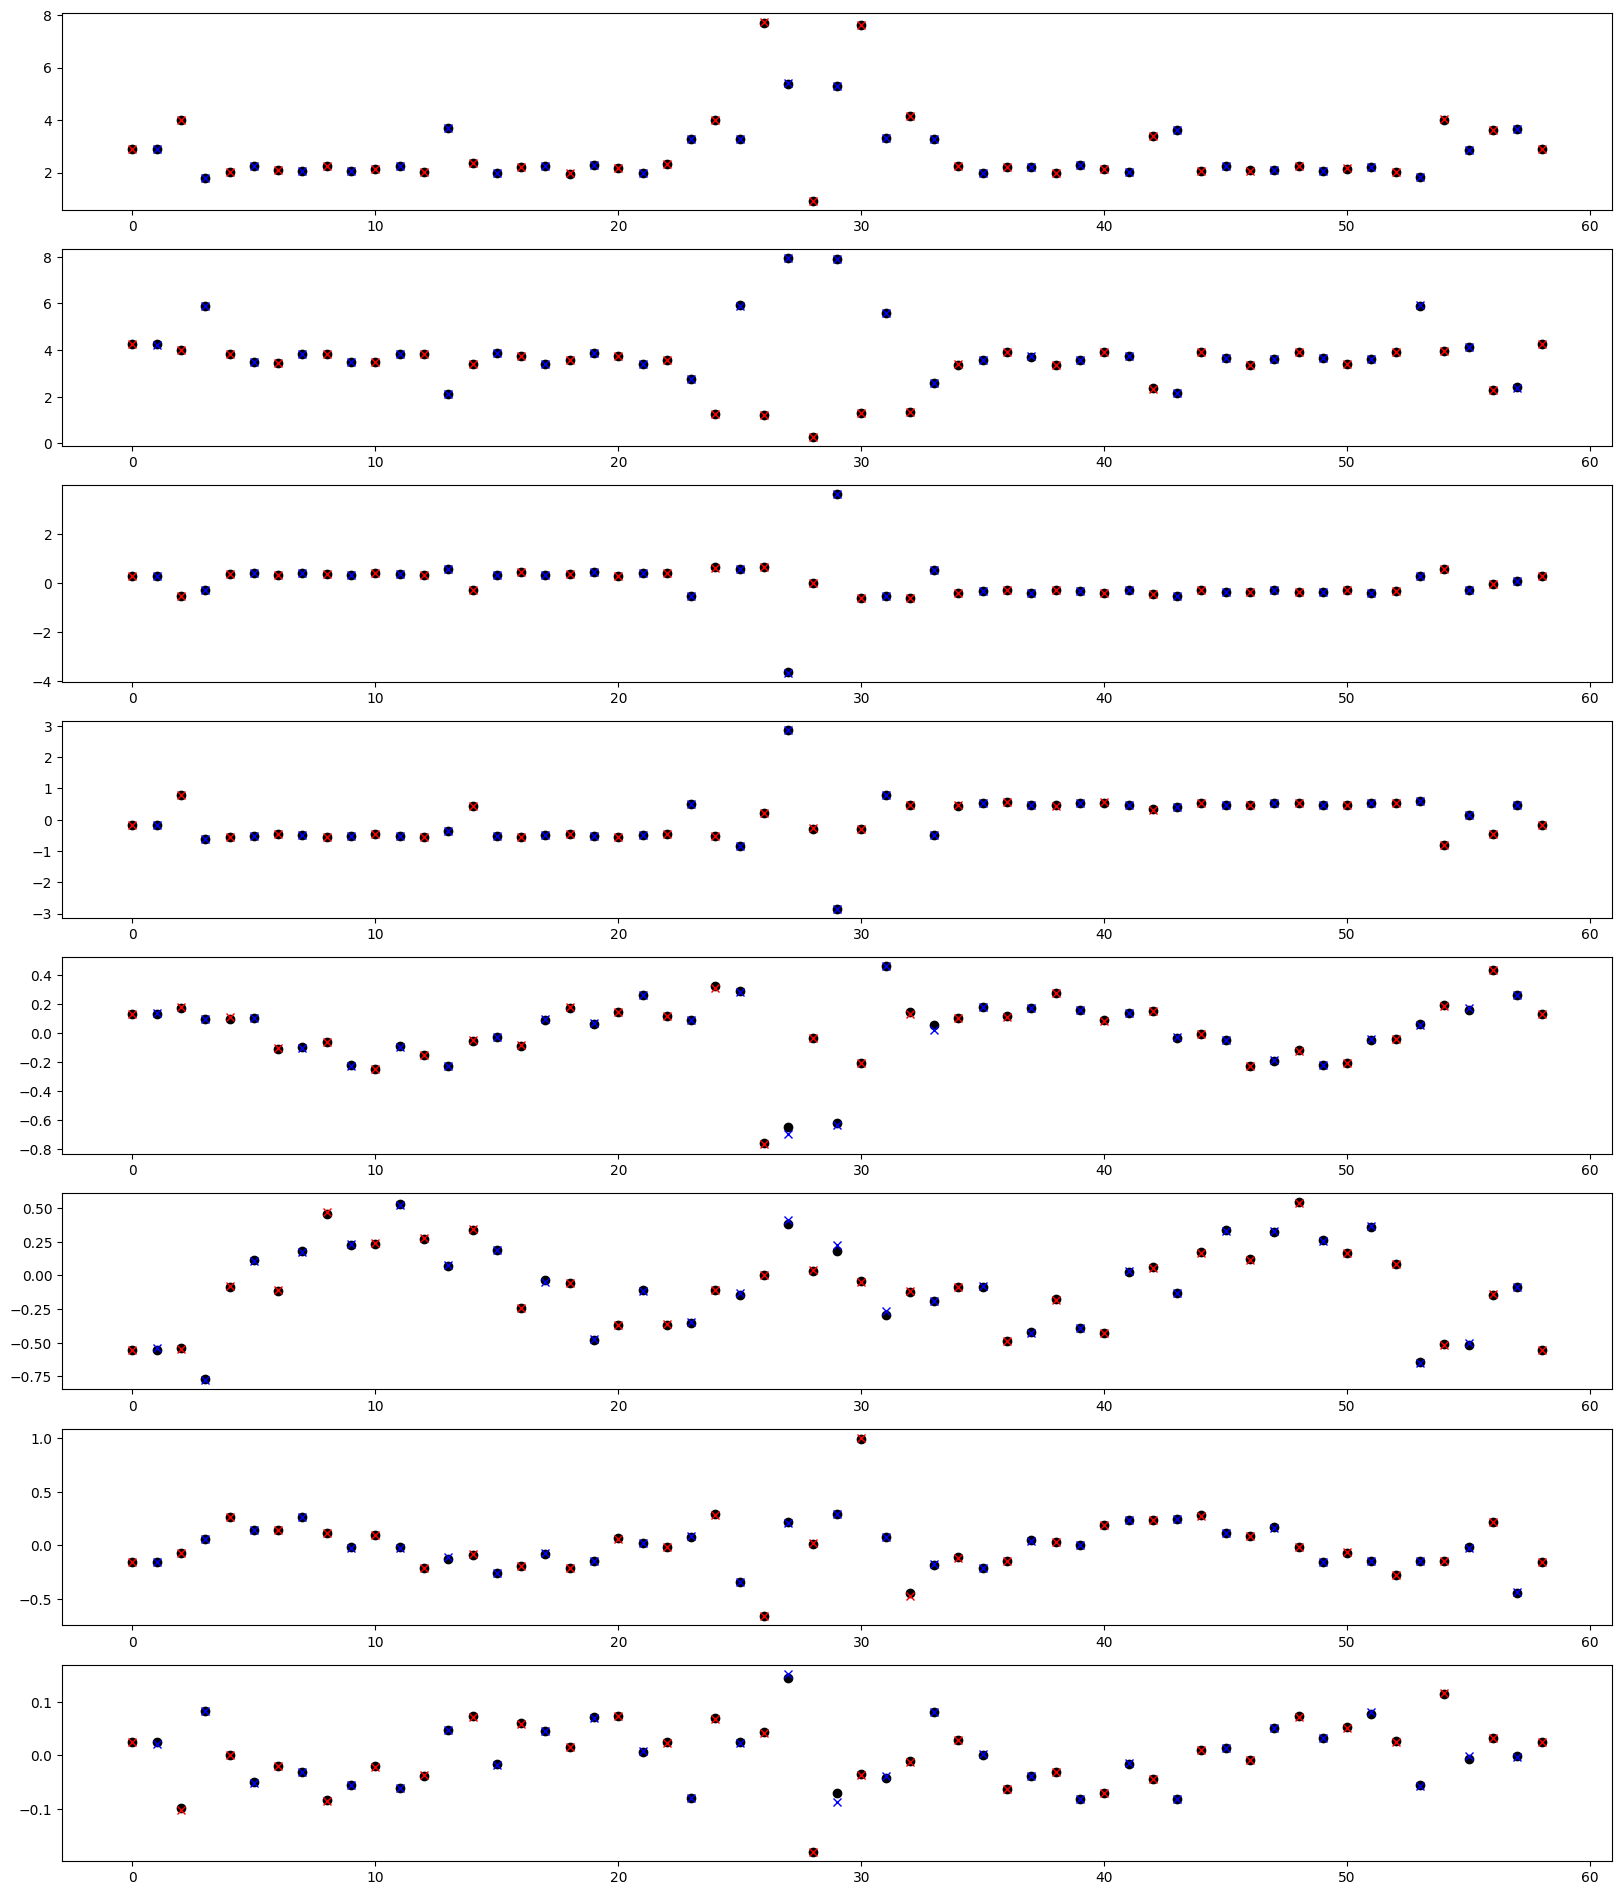

In [29]:
# Compare normalization matrix elements

plt.figure(figsize=(20, 8*3))

ax = plt.subplot(811)
ax.scatter(range(model.size), N11, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n11, yerr=error_n11, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v11, yerr=error_v11, fmt=' ', color='red', marker='x')

ax = plt.subplot(812)
ax.scatter(range(model.size), N33, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n33, yerr=error_n33, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v33, yerr=error_v33, fmt=' ', color='red', marker='x')

ax = plt.subplot(813)
ax.scatter(range(model.size), N21, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n21, yerr=error_n21, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v21, yerr=error_v21, fmt=' ', color='red', marker='x')

ax = plt.subplot(814)
ax.scatter(range(model.size), N43, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n43, yerr=error_n43, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v43, yerr=error_v43, fmt=' ', color='red', marker='x')

ax = plt.subplot(815)
ax.scatter(range(model.size), N13, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n13, yerr=error_n13, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v13, yerr=error_v13, fmt=' ', color='red', marker='x')

ax = plt.subplot(816)
ax.scatter(range(model.size), N31, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n31, yerr=error_n31, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v31, yerr=error_v31, fmt=' ', color='red', marker='x')

ax = plt.subplot(817)
ax.scatter(range(model.size), N14, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n14, yerr=error_n14, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v14, yerr=error_v14, fmt=' ', color='red', marker='x')

ax = plt.subplot(818)
ax.scatter(range(model.size), N41, color='black', marker='o')
ax.errorbar(model.monitor_index, value_n41, yerr=error_n41, fmt=' ', color='blue', marker='x')
ax.errorbar(model.virtual_index, value_v41, yerr=error_v41, fmt=' ', color='red', marker='x')

plt.show()

# black -- true values
# blue  -- monitor locations
# red   -- virtual locations

In [30]:
# Set normal at monitor locations

from harmonica.parameterization import parametric_normal
for index, (n11, n33, n21, n43, n13, n31, n14, n41) in enumerate(zip(value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41)):
    index = model.monitor_index[index]
    normal = parametric_normal(n11, n33, n21, n43, n13, n31, n14, n41, dtype=dtype)
    twiss.normal[index] = normal

# Set normal at virtual locations

from harmonica.parameterization import parametric_normal
for index, (n11, n33, n21, n43, n13, n31, n14, n41) in enumerate(zip(value_v11, value_v33, value_v21, value_v43, value_v13, value_v31, value_v14, value_v41)):
    index = model.virtual_index[index]
    normal = parametric_normal(n11, n33, n21, n43, n13, n31, n14, n41, dtype=dtype)
    twiss.normal[index] = normal

In [31]:
# Transport matrix between locations

numpy.set_printoptions(linewidth=160, formatter = {'all': lambda x: f'{x:.12f}'})

# Set model type ('uncoupled' or 'coupled')

model.model = 'coupled'

# Set probe & other locations

probe = 10
other = 40

print(f'{probe}: {model.is_monitor(probe)}')
print(f'{other}: {model.is_monitor(other)}')
print()

# Exact matrix

matrix_exact = model.map_transport_matrix(probe, other)
print('exact')
print(f'error: {torch.linalg.matrix_norm(matrix_exact - matrix_exact).item():.6e}')
print(matrix_exact.cpu().numpy())
print()

# Model matrix

matrix_model = model.matrix(probe, other)
print('model')
print(f'error: {torch.linalg.matrix_norm(matrix_exact - matrix_model).item():.6e}')
print(matrix_model.cpu().numpy())
print()

# Estimated matrix (virtual twiss)

matrix_twiss = twiss.matrix(probe, other)
print('virtual (twiss)')
print(f'error: {torch.linalg.matrix_norm(matrix_exact - matrix_twiss).item():.6e}')
print(matrix_twiss.cpu().numpy())
print()

# Estimated matrix (virtual matrix)

matrix_twiss = twiss.matrix_virtual(probe, other, close='nearest')
print('virtual (matrix)')
print(f'error: {torch.linalg.matrix_norm(matrix_exact - matrix_twiss).item():.6e}')
print(matrix_twiss.cpu().numpy())
print()

10: False
40: False

exact
error: 0.000000e+00
[[-1.156713341885 4.339421905886 -0.001764371740 0.031314170004]
 [0.087682019471 -1.193554584658 0.003421977694 0.002312385393]
 [0.036022117577 -0.059695132040 -2.085613583244 -12.443949096355]
 [0.006574039011 -0.013982365819 -0.275035510065 -2.120545799457]]

model
error: 1.767477e-01
[[-1.101981284744 4.291362513504 0.000000000000 0.000000000000]
 [0.061607262265 -1.147368937519 0.000000000000 0.000000000000]
 [0.000000000000 0.000000000000 -2.087765916041 -12.316964538171]
 [0.000000000000 0.000000000000 -0.273200163375 -2.090750064735]]

virtual (twiss)
error: 4.189706e-02
[[-1.154918525011 4.331280073286 0.001959184334 0.060346579417]
 [0.086908938848 -1.191959162951 0.003080407095 -0.001465555924]
 [0.039055303373 -0.058381937635 -2.090677029156 -12.470562878022]
 [0.006950718456 -0.015223533955 -0.276628693926 -2.128451321145]]

virtual (matrix)
error: 1.841174e-02
[[-1.155358197393 4.330784313737 -0.000694993729 0.042891610213]


In [32]:
%%time

# Set model type ('uncoupled' or 'coupled')

model.model = 'uncoupled'

# Compute errors for all possible combinations with probe != other

from itertools import product

error_model = []
error_twiss = []
error_close = []

for probe, other in product(range(model.size), repeat=2):
    if probe != other:
        matrix = model.map_transport_matrix(probe, other)
        error_model.append(torch.linalg.matrix_norm(matrix - model.matrix(probe, other)))
        error_twiss.append(torch.linalg.matrix_norm(matrix - twiss.matrix(probe, other)))
        error_close.append(torch.linalg.matrix_norm(matrix - twiss.matrix_virtual(probe, other)))
    
error_model = torch.stack(error_model)
error_twiss = torch.stack(error_twiss)
error_close = torch.stack(error_close)

CPU times: user 47.1 s, sys: 37.6 ms, total: 47.1 s
Wall time: 47.1 s


1108.5367142053751
646.638454828116
641.6935190192893


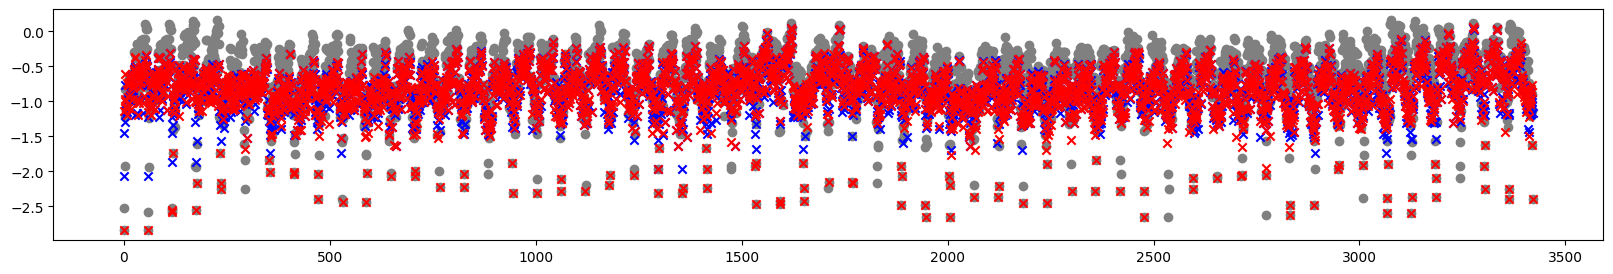

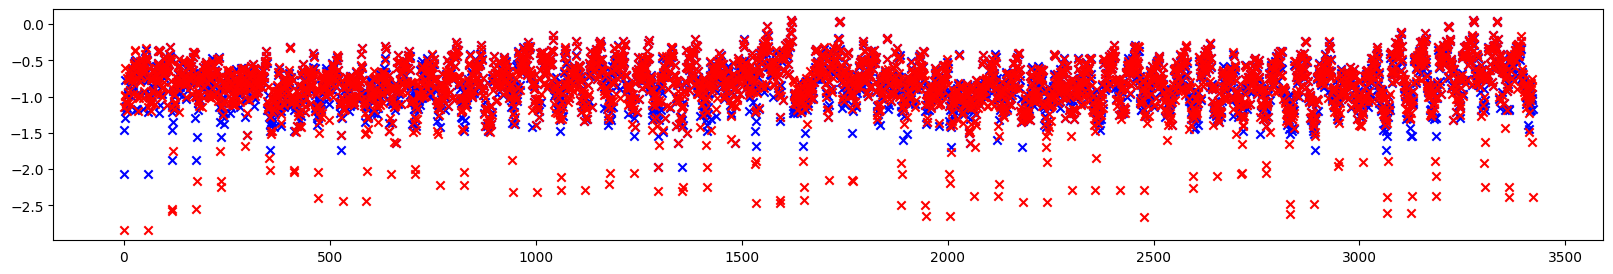

In [33]:
# Plot errors

print(error_model.sum().item())
print(error_twiss.sum().item())
print(error_close.sum().item())

plt.figure(figsize=(20, 3))
plt.scatter(range(len(error_model)), error_model.cpu().log10().numpy(), color='gray', marker='o')
plt.scatter(range(len(error_twiss)), error_twiss.cpu().log10().numpy(), color='blue', marker='x')
plt.scatter(range(len(error_close)), error_close.cpu().log10().numpy(), color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(len(error_twiss)), error_twiss.log10().cpu().numpy(), color='blue', marker='x')
plt.scatter(range(len(error_close)), error_close.log10().cpu().numpy(), color='red', marker='x')
plt.show()

# gray -- model
# blue -- virtual twiss
# red  -- virtual matrix

In [34]:
%%time

# Set model type ('uncoupled' or 'coupled')

model.model = 'coupled'

# Compute errors for all possible combinations with probe != other

from itertools import product

error_model = []
error_twiss = []
error_close = []

for probe, other in product(range(model.size), repeat=2):
    if probe != other:
        matrix = model.map_transport_matrix(probe, other)
        error_model.append(torch.linalg.matrix_norm(matrix - model.matrix(probe, other)))
        error_twiss.append(torch.linalg.matrix_norm(matrix - twiss.matrix(probe, other)))
        error_close.append(torch.linalg.matrix_norm(matrix - twiss.matrix_virtual(probe, other)))
    
error_model = torch.stack(error_model)
error_twiss = torch.stack(error_twiss)
error_close = torch.stack(error_close)

CPU times: user 39.9 s, sys: 21 ms, total: 40 s
Wall time: 40 s


1108.5367142054456
208.2201978363385
246.39317146505502


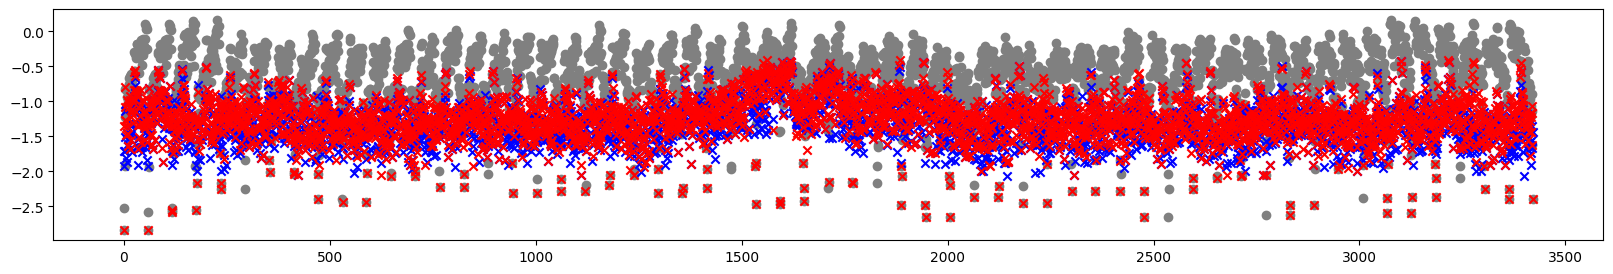

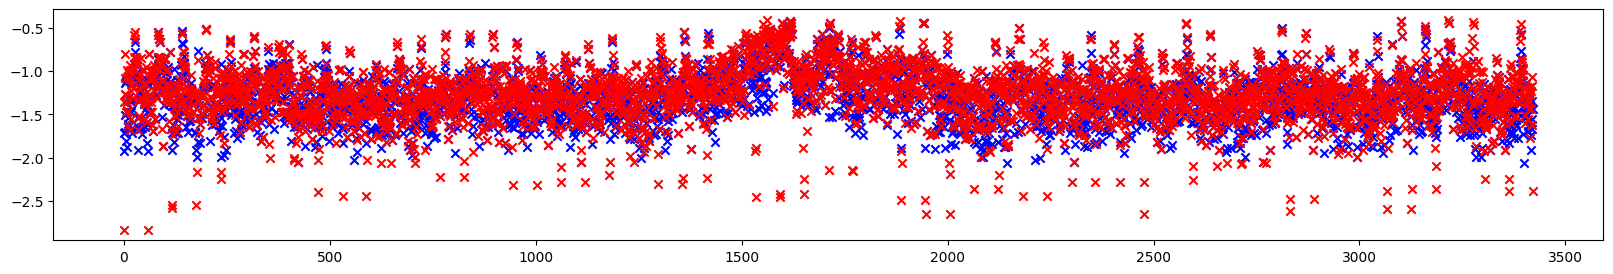

In [35]:
# Plot errors

print(error_model.sum().item())
print(error_twiss.sum().item())
print(error_close.sum().item())

plt.figure(figsize=(20, 3))
plt.scatter(range(len(error_model)), error_model.cpu().log10().numpy(), color='gray', marker='o')
plt.scatter(range(len(error_twiss)), error_twiss.cpu().log10().numpy(), color='blue', marker='x')
plt.scatter(range(len(error_close)), error_close.cpu().log10().numpy(), color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(range(len(error_twiss)), error_twiss.log10().cpu().numpy(), color='blue', marker='x')
plt.scatter(range(len(error_close)), error_close.log10().cpu().numpy(), color='red', marker='x')
plt.show()

# gray -- model
# blue -- virtual twiss
# red  -- virtual matrix